# Pré-processamento — Abordagem por Embeddings

Tema 14 – Fake News e Informação Online

Este notebook produz a representação vetorial do dataset FactCenter usando **sentence embeddings** multilíngues, como base para a EDA e clusterização.

Pipeline:
1. Carregamento e limpeza textual
2. Normalização dos rótulos de verificação (rating)
3. Geração de embeddings com `paraphrase-multilingual-MiniLM-L12-v2`
4. Redução de dimensionalidade com PCA e UMAP
5. Persistência dos artefatos para uso nas etapas seguintes

## 1. Importações

In [1]:
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from pathlib import Path
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances
import umap

SEED = 42
np.random.seed(SEED)

## 2. Carregamento do dataset

In [2]:
DATASET_PATH = "../../dataset/central_de_fatos.csv"
ARTIFACTS_DIR = Path("../../artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATASET_PATH, sep=";")
print(f"Registros carregados: {df.shape[0]}")
df.head(3)

Registros carregados: 11647


,url,source_name,title,subtitle,publication_date,text_news,image_link,video_link,authors,categories,tags,obtained_at,rating
0,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Publicações enganam ao associar Bolsonaro à ap...,NaN,2020-07-31,Ancine aprovou em 2019 a captação de 530 mil r...,NaN,NaN,['Projeto Comprova'],['Políticas públicas'],[],2021-07-06,['Enganoso']
1,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Post mostra imagens de outras estradas para af...,NaN,2020-07-31,Parte dos trechos das gravações utilizadas no ...,https://i2.wp.com/projetocomprova.com.br/wp-co...,NaN,['Projeto Comprova'],['Políticas públicas'],[],2021-07-06,['Falso']
2,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Eduardo Bolsonaro posta vídeo antigo sobre lib...,NaN,2020-07-31,"Em uma publicação no Twitter, o deputado usa c...",NaN,NaN,['Projeto Comprova'],['Pandemia'],[],2021-07-06,['Enganoso']


## 3. Parsing de colunas serializadas como lista

In [3]:
def parse_list_column(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    value = str(value).strip()
    if not value or value.lower() in ("nan", "none", "null"):
        return []
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [str(i).strip().lower() for i in parsed if str(i).strip()]
        return [str(parsed).strip()]
    except (ValueError, SyntaxError):
        return [value]

for col in ("authors", "categories", "tags", "rating"):
    df[col] = df[col].apply(parse_list_column)

df["publication_date"] = pd.to_datetime(df["publication_date"], errors="coerce")
df["obtained_at"]      = pd.to_datetime(df["obtained_at"],      errors="coerce")

## 4. Limpeza básica

In [4]:
df = df.drop_duplicates(subset=["url"])

df = df[
    df["title"].notna() &
    df["text_news"].notna() &
    df["authors"].map(len).gt(0)
].copy()

df["source_name"] = df["source_name"].str.strip().str.lower()

print(f"Registros após limpeza: {df.shape[0]}")

Registros após limpeza: 11539


## 5. Normalização dos rótulos de verificação (rating)

O dataset possui mais de 20 variações de rótulo (`boato`, `fake`, `falso`, `enganoso`, `impreciso`, etc.).
Consolidamos em quatro classes canônicas para facilitar análises e colorir visualizações.

In [5]:
RATING_MAP = {
    # falso
    "boato":       "falso",
    "falso":       "falso",
    "fake":        "falso",
    # enganoso
    "enganoso":             "enganoso",
    "impreciso":            "enganoso",
    "distorcido":           "enganoso",
    "exagerado":            "enganoso",
    "fora de contexto":     "enganoso",
    "contraditório":        "enganoso",
    "insustentável":        "enganoso",
    "nao e bem assim":      "enganoso",
    "verdadeiro, mas":      "enganoso",
    "subestimado":          "enganoso",
    "contexto errado":      "enganoso",
    # verdadeiro
    "verdadeiro":           "verdadeiro",
    "comprovado":           "verdadeiro",
    "fato":                 "verdadeiro",
    "evidência comprovada": "verdadeiro",
    # inconclusivo
    "ainda é cedo para dizer": "inconclusivo",
    "de olho":                 "inconclusivo",
}

def normalize_rating(lst):
    if not lst:
        return "sem_rating"
    return RATING_MAP.get(lst[0].strip().lower(), "outros")

df["rating_norm"] = df["rating"].apply(normalize_rating)

print(df["rating_norm"].value_counts())

rating_norm
falso           10142
enganoso         1129
verdadeiro        204
inconclusivo       64
Name: count, dtype: int64


## 6. Limpeza textual

Antes de gerar embeddings removemos ruídos que não contribuem para o significado semântico:
URLs, caracteres especiais e espaços extras.

> **Nota sobre truncamento:** o modelo `MiniLM-L12-v2` aceita no máximo 128 tokens por padrão
> (configurável até 512). Como os textos têm em média ~690 palavras, concatenamos
> `título (x2) + primeiros 400 chars do texto` para priorizar o sinal mais denso
> e evitar que o conteúdo relevante seja truncado pelo modelo.

In [6]:
def clean_text(text: str) -> str:
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-záéíóúâêîôûãõàçA-ZÁÉÍÓÚÂÊÎÔÛÃÕÀÇ\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip().lower()

df["title_clean"] = df["title"].astype(str).apply(clean_text)
df["text_clean"]  = df["text_news"].astype(str).apply(clean_text)

# título repetido 2x para aumentar seu peso relativo no embedding
df["content"] = (
    df["title_clean"] + " " +
    df["title_clean"] + " " +
    df["text_clean"].str[:400]
)

print("Exemplo de conteúdo preparado:")
print(df["content"].iloc[0])

Exemplo de conteúdo preparado:
publicações enganam ao associar bolsonaro à aprovação de verba para filme sobre sua eleição publicações enganam ao associar bolsonaro à aprovação de verba para filme sobre sua eleição ancine aprovou em a captação de mil reais para a realização de um filme que trata da eleição de bolsonaro mas não liberou recursos diretos para o documentário como dão a entender duas postagens investigadas pelo comprova conteúdo verificado informação compartilhada no twitter e no facebook afirma que bolsonaro teria liberado via ancine mil reais para a produção de um filme sobre ele mesmo duas pos


## 7. Geração de embeddings

Modelo escolhido: `paraphrase-multilingual-MiniLM-L12-v2`
- Multilíngue — treinado com português incluído
- 384 dimensões de saída
- Tamanho ~120 MB, viável em CPU

Os embeddings são salvos em disco após a primeira execução para evitar recomputação.

**Tempo esperado em CPU:** ~15–30 min para 11k documentos.

In [7]:
EMBEDDINGS_PATH = ARTIFACTS_DIR / "embeddings.npy"

if EMBEDDINGS_PATH.exists():
    print("Carregando embeddings salvos em disco...")
    embeddings = np.load(EMBEDDINGS_PATH)
else:
    print("Gerando embeddings (primeira execução — pode demorar)...")
    model = SentenceTransformer("rufimelo/bert-large-portuguese-cased-sts") # paraphrase-multilingual-MiniLM-L12-v2 // rufimelo/bert-large-portuguese-cased-sts
    embeddings = model.encode(
        df["content"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f"Embeddings salvos em {EMBEDDINGS_PATH}")

print(f"Shape dos embeddings: {embeddings.shape}")

Carregando embeddings salvos em disco...
Shape dos embeddings: (11539, 1024)


## 8. Variância explicada por componente principal

Verificamos quantas dimensões PCA retêm 90% e 95% da variância dos embeddings
para escolher o número de componentes a usar na etapa de clustering.

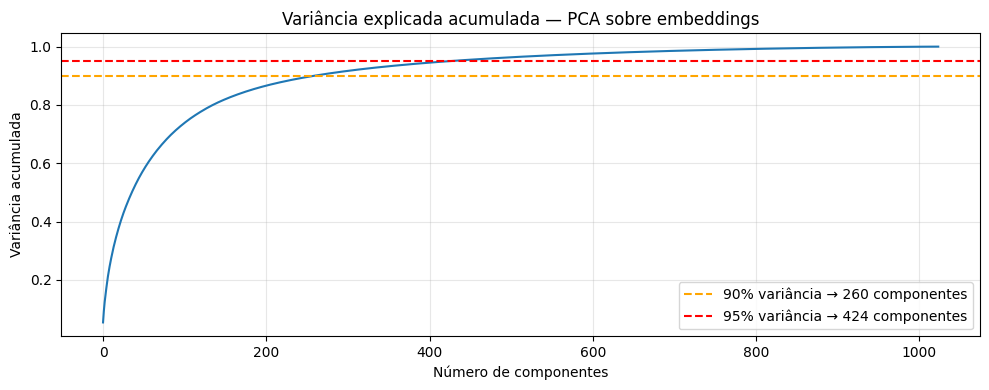

Componentes para 90% de variância: 260
Componentes para 95% de variância: 424


In [8]:
pca_full = PCA(random_state=SEED)
pca_full.fit(embeddings)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.searchsorted(cumvar, 0.90)) + 1
n_95 = int(np.searchsorted(cumvar, 0.95)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cumvar, linewidth=1.5)
ax.axhline(0.90, color="orange", linestyle="--", label=f"90% variância → {n_90} componentes")
ax.axhline(0.95, color="red",    linestyle="--", label=f"95% variância → {n_95} componentes")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Variância acumulada")
ax.set_title("Variância explicada acumulada — PCA sobre embeddings")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Componentes para 90% de variância: {n_90}")
print(f"Componentes para 95% de variância: {n_95}")

## 9. Redução com PCA para clustering

Usamos os componentes que retêm 95% da variância como representação densa
para os algoritmos de clustering (K-Means, DBSCAN, Hierárquico).

In [9]:
pca = PCA(n_components=n_95, random_state=SEED)
X_pca = pca.fit_transform(embeddings)

print(f"Shape após PCA: {X_pca.shape}")
print(f"Variância retida: {pca.explained_variance_ratio_.sum():.3f}")

Shape após PCA: (11539, 424)
Variância retida: 0.949


## 10. Redução com UMAP para visualização 2D

UMAP aplicado sobre `X_pca` (não sobre os embeddings brutos) para maior estabilidade.

- `n_neighbors=15`: controla o balanço entre estrutura local e global
- `min_dist=0.1`: controla a compactação visual dos clusters
- `metric="cosine"`: adequada para espaços de embedding

In [10]:
UMAP_PATH = ARTIFACTS_DIR / "umap_2d.npy"

if UMAP_PATH.exists():
    print("Carregando projeção UMAP salva em disco...")
    X_umap = np.load(UMAP_PATH)
else:
    print("Calculando projeção UMAP...")
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=SEED,
    )
    X_umap = reducer.fit_transform(X_pca)
    np.save(UMAP_PATH, X_umap)
    print(f"Projeção UMAP salva em {UMAP_PATH}")

print(f"Shape UMAP 2D: {X_umap.shape}")

Carregando projeção UMAP salva em disco...
Shape UMAP 2D: (11539, 2)


## 11. Visualização UMAP colorida por rating

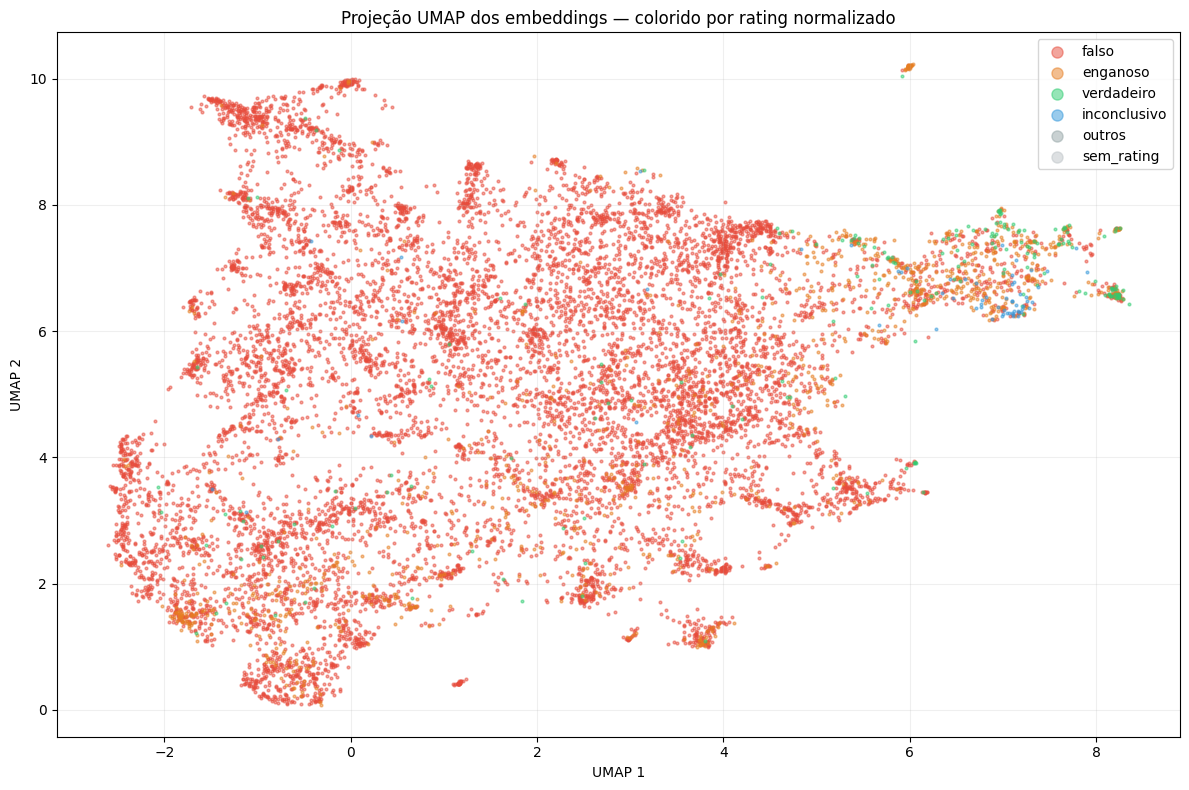

In [11]:
PALETTE = {
    "falso":        "#e74c3c",
    "enganoso":     "#e67e22",
    "verdadeiro":   "#2ecc71",
    "inconclusivo": "#3498db",
    "outros":       "#95a5a6",
    "sem_rating":   "#bdc3c7",
}

fig, ax = plt.subplots(figsize=(12, 8))

for label, color in PALETTE.items():
    mask = df["rating_norm"].values == label
    ax.scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        s=4, alpha=0.5, color=color, label=label, rasterized=True,
    )

ax.set_title("Projeção UMAP dos embeddings — colorido por rating normalizado")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(markerscale=4, loc="best")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 12. Visualização UMAP colorida por agência (source_name)

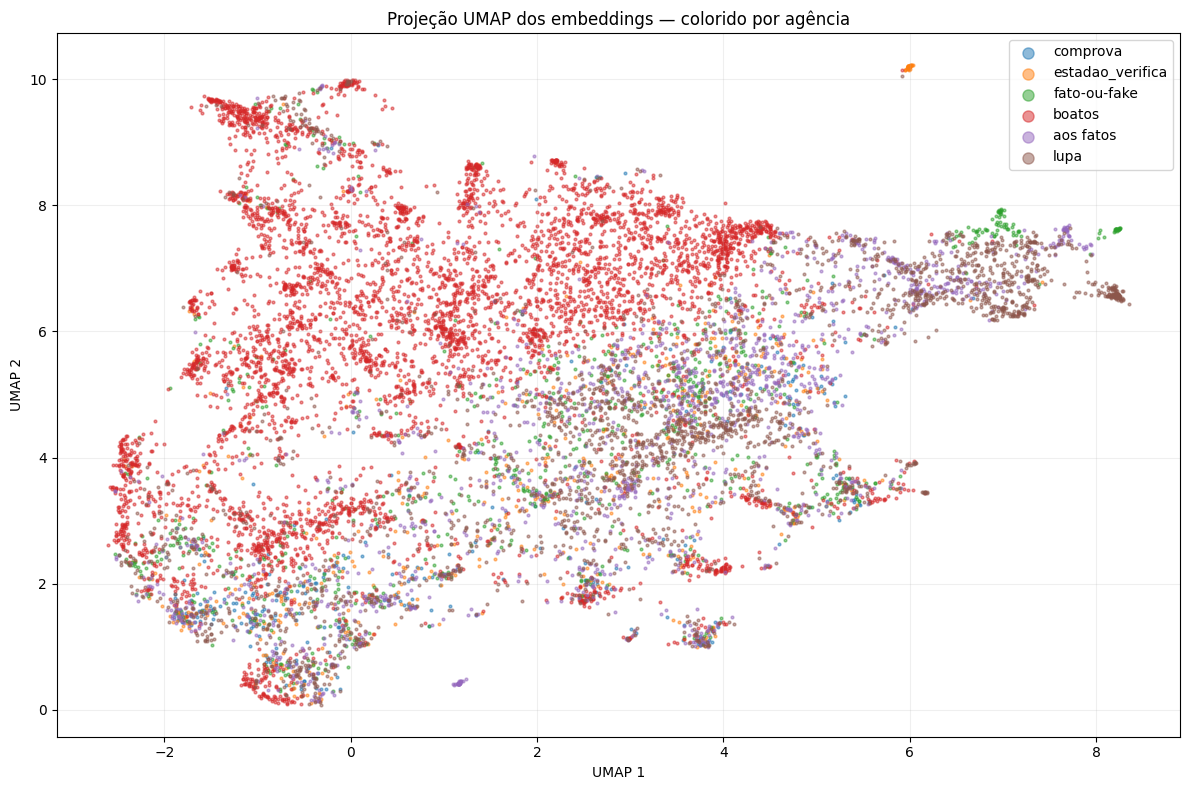

In [12]:
sources = df["source_name"].unique()
palette_src = dict(zip(sources, cm.tab10.colors[:len(sources)]))

fig, ax = plt.subplots(figsize=(12, 8))

for src, color in palette_src.items():
    mask = df["source_name"].values == src
    ax.scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        s=4, alpha=0.5, color=color, label=src, rasterized=True,
    )

ax.set_title("Projeção UMAP dos embeddings — colorido por agência")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(markerscale=4, loc="best")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 13. Análise de distâncias intra/inter-classe

Calculamos as distâncias cosseno médias dentro de cada classe de rating e entre classes.
Valores intra-classe menores que inter-classe indicam que os embeddings capturam
separação semântica real entre as categorias — o que favorece clustering bem definido.

Usamos amostras de no máximo 500 documentos por classe para viabilidade computacional.

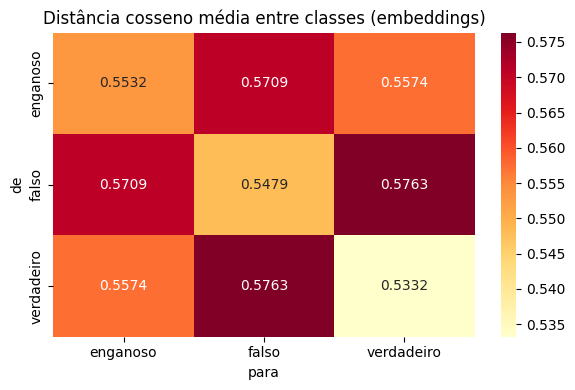

para,enganoso,falso,verdadeiro
de,,,
enganoso,0.5532,0.5709,0.5574
falso,0.5709,0.5479,0.5763
verdadeiro,0.5574,0.5763,0.5332


In [13]:
MAIN_CLASSES = ["falso", "enganoso", "verdadeiro"]

samples = {}
for cls in MAIN_CLASSES:
    idx = np.where(df["rating_norm"].values == cls)[0]
    samples[cls] = np.random.choice(idx, size=min(500, len(idx)), replace=False)

rows, cols_list, dists = [], [], []
for cls_a in MAIN_CLASSES:
    for cls_b in MAIN_CLASSES:
        d = cosine_distances(
            embeddings[samples[cls_a]],
            embeddings[samples[cls_b]],
        ).mean()
        rows.append(cls_a)
        cols_list.append(cls_b)
        dists.append(round(d, 4))

dist_df = pd.DataFrame({"de": rows, "para": cols_list, "dist_cosseno_media": dists})
dist_pivot = dist_df.pivot(index="de", columns="para", values="dist_cosseno_media")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(dist_pivot, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax)
ax.set_title("Distância cosseno média entre classes (embeddings)")
plt.tight_layout()
plt.show()

dist_pivot

## 14. Persistência dos artefatos

Salvamos os artefatos necessários para as etapas de EDA e clustering:

| Arquivo | Conteúdo | Usado em |
|---|---|---|
| `embeddings.npy` | Vetores brutos 384-dim | Comparações de distância |
| `X_pca.npy` | Componentes PCA (95% variância) | Clustering (K-Means, DBSCAN, Hierárquico) |
| `umap_2d.npy` | Projeção 2D | Visualizações |
| `df_clean.parquet` | DataFrame com metadados + rating_norm | Interpretação dos clusters |

In [14]:
np.save(ARTIFACTS_DIR / "X_pca.npy", X_pca)

cols_to_save = [
    "url", "source_name", "title", "publication_date",
    "categories", "rating", "rating_norm",
    "title_clean", "content",
]
df[cols_to_save].to_parquet(ARTIFACTS_DIR / "df_clean.parquet", index=False)

print("Artefatos salvos:")
for f in sorted(ARTIFACTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:30s} {size_kb:8.1f} KB")

Artefatos salvos:
  X_pca.npy                       19111.6 KB
  df_clean.parquet                 4582.1 KB
  embeddings.npy                  46156.1 KB
  umap_2d.npy                        90.3 KB


## 15. Resumo

| Etapa | Resultado |
|---|---|
| Registros após limpeza | ~11.539 |
| Dimensão dos embeddings brutos | 384 |
| Dimensão após PCA (95% variância) | calculado na célula 9 |
| Dimensão para visualização (UMAP) | 2 |
| Métrica de distância recomendada | Cosseno |